In [10]:
print(" BIENVENUE DANS MON PREMIER PROJET MACHINE LEARNING !")
print(" Objectif : Créer un modèle qui prédit le prix des maisons")
print("=" * 70)

 BIENVENUE DANS MON PREMIER PROJET MACHINE LEARNING !
 Objectif : Créer un modèle qui prédit le prix des maisons


In [2]:
# ===============================================================================
# IMPORTS ET SETUP
# ===============================================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Nouveaux outils pour le Machine Learning !
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')


In [3]:
# ===============================================================================
# CRÉATION DU DATASET RÉALISTE 
# ===============================================================================

print("\n\nCréation de notre dataset")
print("-" * 50)

# Génération de données réalistes
np.random.seed(42)  # Pour avoir les mêmes résultats à chaque fois
n_maisons = 800

# Variables explicatives (features)
quartiers = ['Centre-ville', 'Banlieue', 'Périphérie', 'Zone résidentielle', 'Zone commerciale']
types_maison = ['Appartement', 'Maison', 'Villa', 'Studio']
etats = ['Neuf', 'Bon', 'À rénover', 'Ancien']

# Création du dataset
data_maisons = {
    'superficie_m2': np.random.randint(25, 250, n_maisons),
    'nb_pieces': np.random.randint(1, 8, n_maisons),
    'quartier': np.random.choice(quartiers, n_maisons),
    'type_logement': np.random.choice(types_maison, n_maisons),
    'etat': np.random.choice(etats, n_maisons),
    'annee_construction': np.random.randint(1970, 2024, n_maisons),
    'balcon': np.random.choice([0, 1], n_maisons, p=[0.4, 0.6]),  # 60% ont un balcon
    'garage': np.random.choice([0, 1], n_maisons, p=[0.3, 0.7]),  # 70% ont un garage
    'proximite_metro': np.random.choice([0, 1], n_maisons, p=[0.5, 0.5])  # 50% proche métro
}

df_maisons = pd.DataFrame(data_maisons)



Création de notre dataset
--------------------------------------------------


In [11]:
# ===============================================================================
# GÉNÉRATION DU PRIX 
# ===============================================================================

print("\nGénération des prix basée sur une logique réaliste...")

# Prix de base selon les caractéristiques
prix_base_quartier = {
    'Centre-ville': 8000, 'Banlieue': 5000, 'Périphérie': 3500, 
    'Zone résidentielle': 6000, 'Zone commerciale': 4500
}

prix_base_type = {
    'Appartement': 1.0, 'Maison': 1.2, 'Villa': 1.5, 'Studio': 0.8
}

prix_base_etat = {
    'Neuf': 1.3, 'Bon': 1.0, 'À rénover': 0.7, 'Ancien': 0.9
}

# Calcul du prix avec logique + aléa réaliste
def calculer_prix(row):
    prix_m2 = prix_base_quartier[row['quartier']]
    
    # Prix de base
    prix = (row['superficie_m2'] * prix_m2 * 
           prix_base_type[row['type_logement']] * 
           prix_base_etat[row['etat']])
    
    # Bonus pour caractéristiques
    if row['balcon']: prix *= 1.1
    if row['garage']: prix *= 1.15
    if row['proximite_metro']: prix *= 1.2
    
    # Bonus pour récent
    if row['annee_construction'] > 2000: prix *= 1.1
    
    # Ajout d'aléa réaliste
    prix += np.random.normal(0, prix * 0.1)
    
    return max(prix, 50000)  # Prix minimum

df_maisons['prix'] = df_maisons.apply(calculer_prix, axis=1).round(-3)

# Injection de valeurs manquantes pour rendre réaliste
missing_indices = np.random.choice(df_maisons.index, size=40, replace=False)
df_maisons.loc[missing_indices[:20], 'annee_construction'] = np.nan
df_maisons.loc[missing_indices[20:], 'nb_pieces'] = np.nan

print(f" Dataset créé : {len(df_maisons)} maisons")
print(f" Variables : {list(df_maisons.columns)}")
print(f" Prix moyen : {df_maisons['prix'].mean():,.0f}€")
print(f" Superficie moyenne : {df_maisons['superficie_m2'].mean():.0f}m²")

print(f"\n Aperçu des données :")
print(df_maisons.head(10))



Génération des prix basée sur une logique réaliste...
 Dataset créé : 800 maisons
 Variables : ['superficie_m2', 'nb_pieces', 'quartier', 'type_logement', 'etat', 'annee_construction', 'balcon', 'garage', 'proximite_metro', 'prix']
 Prix moyen : 1,106,108€
 Superficie moyenne : 140m²

 Aperçu des données :
   superficie_m2  nb_pieces            quartier type_logement       etat  \
0            127        3.0        Centre-ville   Appartement     Ancien   
1            204        5.0            Banlieue        Studio        Bon   
2            117        4.0    Zone commerciale        Maison        Bon   
3             39        6.0  Zone résidentielle   Appartement        Bon   
4            131        NaN          Périphérie        Maison  À rénover   
5             96        7.0  Zone résidentielle         Villa  À rénover   
6            213        4.0            Banlieue         Villa     Ancien   
7             45        1.0  Zone résidentielle         Villa     Ancien   
8      



EXPLORATION AVANCÉE 
------------------------------------------------------------
 INFORMATIONS GÉNÉRALES :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   superficie_m2       800 non-null    int64  
 1   nb_pieces           762 non-null    float64
 2   quartier            800 non-null    object 
 3   type_logement       800 non-null    object 
 4   etat                800 non-null    object 
 5   annee_construction  761 non-null    float64
 6   balcon              800 non-null    int64  
 7   garage              800 non-null    int64  
 8   proximite_metro     800 non-null    int64  
 9   prix                800 non-null    float64
dtypes: float64(3), int64(4), object(3)
memory usage: 62.6+ KB
None

 STATISTIQUES DESCRIPTIVES :
       superficie_m2  nb_pieces  annee_construction  balcon  garage  \
count          800.0      76

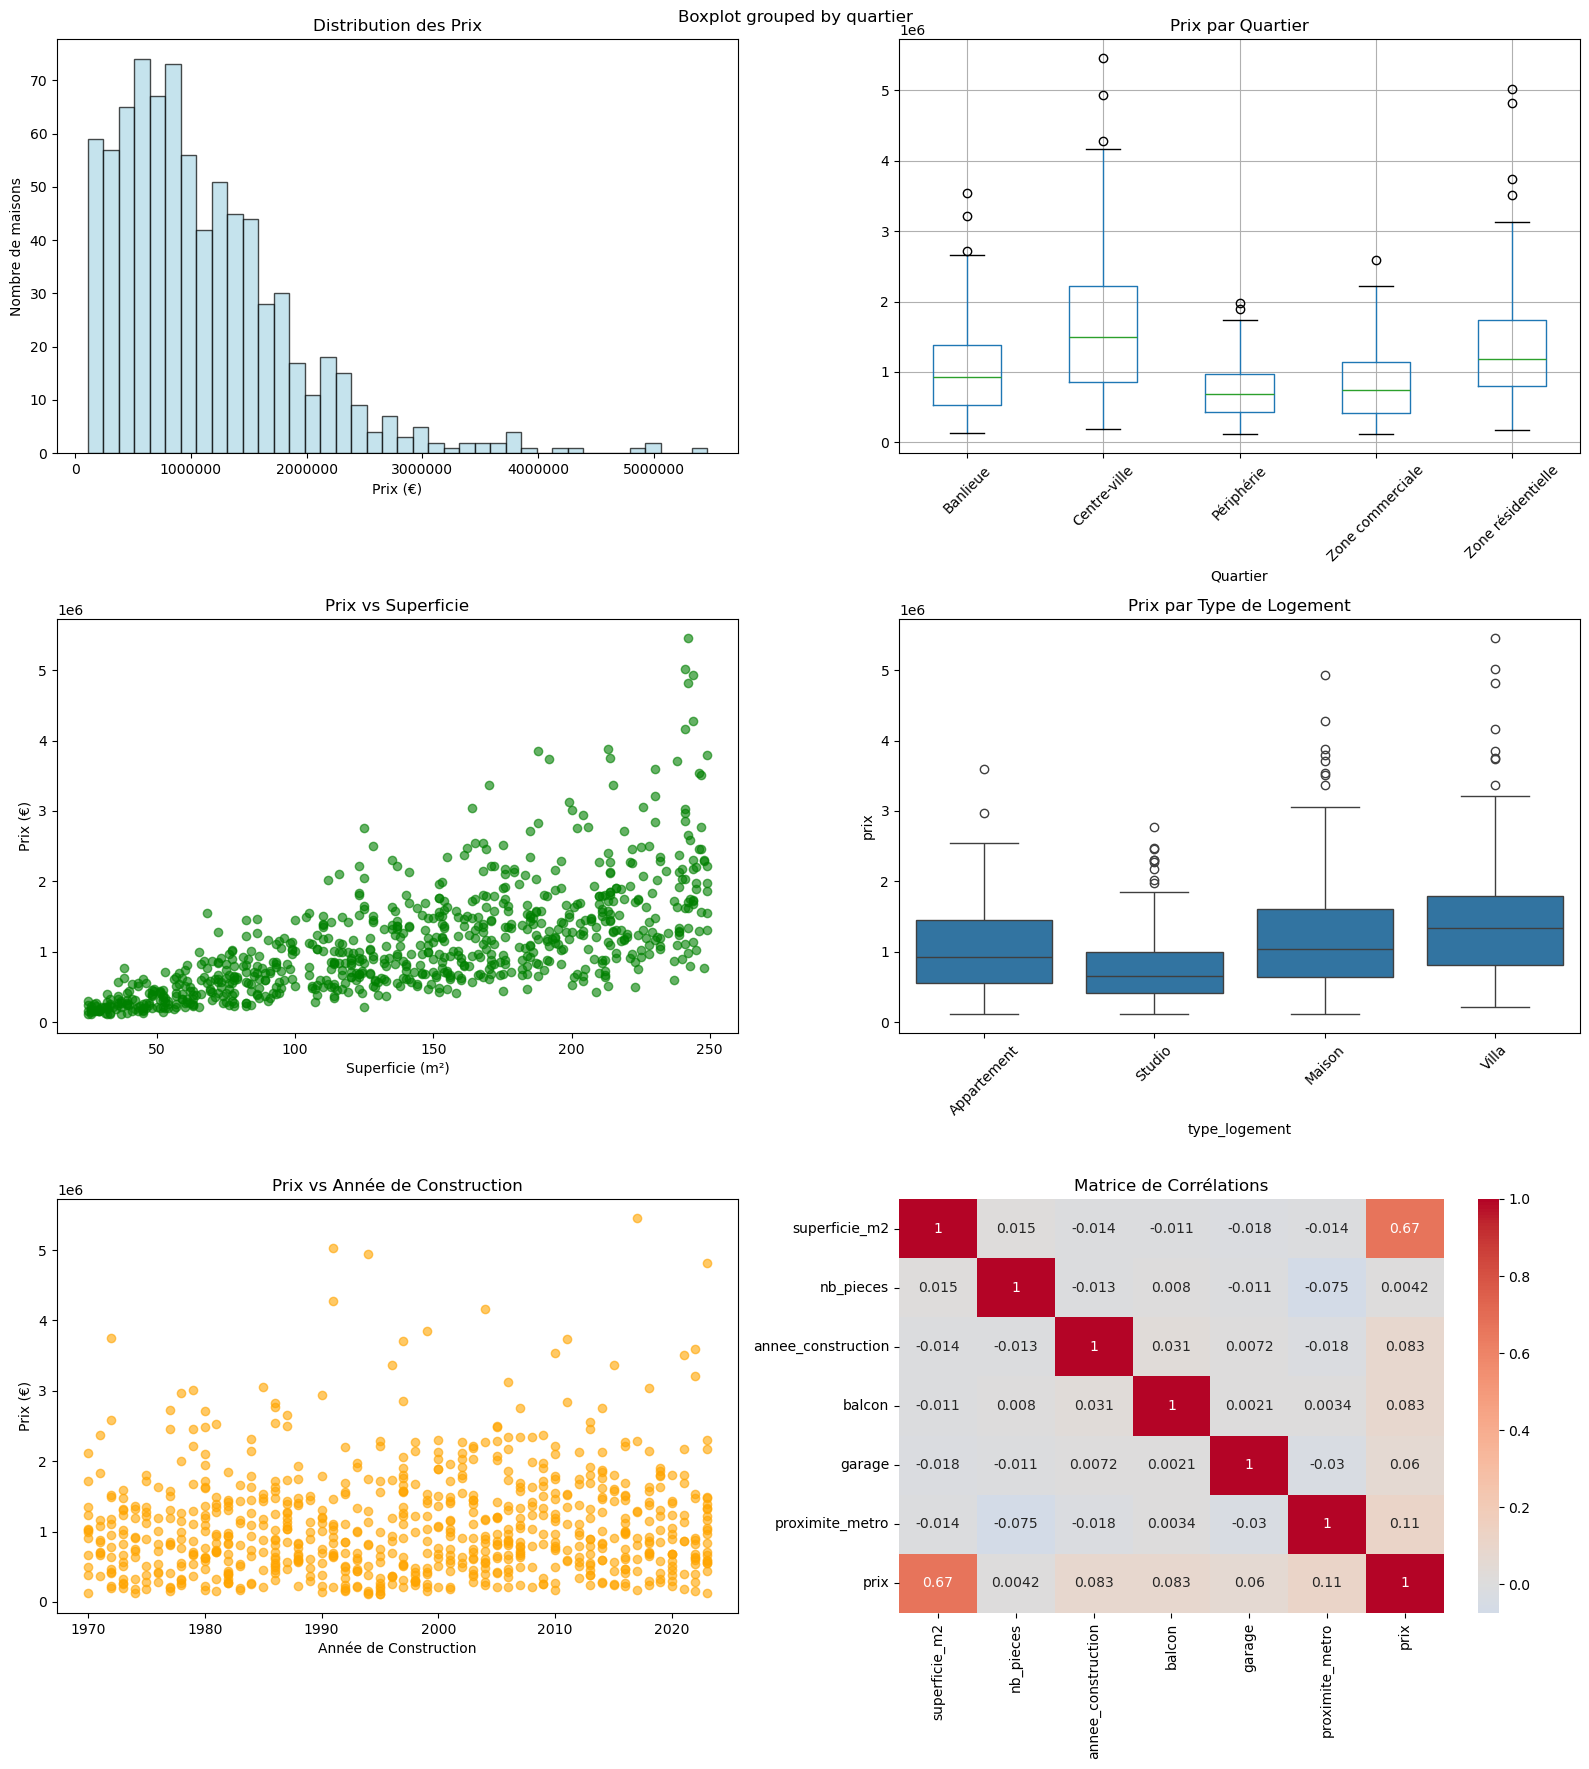

In [12]:
# ===============================================================================
# EXPLORATION AVANCÉE DES DONNÉES
# ===============================================================================

print("\n\nEXPLORATION AVANCÉE ")
print("-" * 60)

# Informations générales
print(" INFORMATIONS GÉNÉRALES :")
print(df_maisons.info())
print(f"\n STATISTIQUES DESCRIPTIVES :")
print(df_maisons.describe().round(0))

# Valeurs manquantes
print(f"\nVALEURS MANQUANTES :")
missing = df_maisons.isnull().sum()
print(missing[missing > 0])

# Visualisations avancées
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle(' ANALYSE EXPLORATOIRE - MARCHÉ IMMOBILIER', fontsize=16, fontweight='bold')

# 1. Distribution des prix
axes[0, 0].hist(df_maisons['prix'], bins=40, color='lightblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Distribution des Prix')
axes[0, 0].set_xlabel('Prix (€)')
axes[0, 0].set_ylabel('Nombre de maisons')
axes[0, 0].ticklabel_format(style='plain', axis='x')

# 2. Prix par quartier
df_maisons.boxplot(column='prix', by='quartier', ax=axes[0, 1])
axes[0, 1].set_title('Prix par Quartier')
axes[0, 1].set_xlabel('Quartier')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Relation superficie vs prix
axes[1, 0].scatter(df_maisons['superficie_m2'], df_maisons['prix'], alpha=0.6, color='green')
axes[1, 0].set_title('Prix vs Superficie')
axes[1, 0].set_xlabel('Superficie (m²)')
axes[1, 0].set_ylabel('Prix (€)')

# 4. Prix par type de logement
sns.boxplot(data=df_maisons, x='type_logement', y='prix', ax=axes[1, 1])
axes[1, 1].set_title('Prix par Type de Logement')
axes[1, 1].tick_params(axis='x', rotation=45)

# 5. Effet de l'année de construction
axes[2, 0].scatter(df_maisons['annee_construction'], df_maisons['prix'], alpha=0.6, color='orange')
axes[2, 0].set_title('Prix vs Année de Construction')
axes[2, 0].set_xlabel('Année de Construction')
axes[2, 0].set_ylabel('Prix (€)')

# 6. Corrélations
numeric_cols = ['superficie_m2', 'nb_pieces', 'annee_construction', 'balcon', 'garage', 'proximite_metro', 'prix']
correlation_matrix = df_maisons[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[2, 1])
axes[2, 1].set_title('Matrice de Corrélations')

plt.tight_layout()
plt.show()



In [20]:
# ===============================================================================
# NETTOYAGE ET FEATURE ENGINEERING
# ===============================================================================

print("\n\nNETTOYAGE AVANCÉ ET FEATURE ENGINEERING")
print("-" * 60)

# Copie pour le nettoyage
df_clean = df_maisons.copy()

# 1. Traitement des valeurs manquantes (stratégie intelligente)
print(" Traitement intelligent des valeurs manquantes...")

# Pour année_construction : remplacer par la médiane du quartier
df_clean['annee_construction'] = df_clean.groupby('quartier')['annee_construction'].transform(
    lambda x: x.fillna(x.median())
)

# Pour nb_pieces : remplacer par la médiane selon la superficie
df_clean['nb_pieces'] = df_clean.groupby(pd.cut(df_clean['superficie_m2'], bins=5))['nb_pieces'].transform(
    lambda x: x.fillna(x.median())
)

print(f" Valeurs manquantes après traitement : {df_clean.isnull().sum().sum()}")

# 2. Feature Engineering (création de nouvelles variables)
print(" Création de nouvelles features intelligentes...")

# Feature 1 : Âge de la maison
df_clean['age_maison'] = 2024 - df_clean['annee_construction']

# Feature 2 : Prix au m²
df_clean['prix_m2'] = df_clean['prix'] / df_clean['superficie_m2']

# Feature 3 : Surface par pièce
df_clean['surface_par_piece'] = df_clean['superficie_m2'] / df_clean['nb_pieces']

# Feature 4 : Score de commodité (combine balcon, garage, métro)
df_clean['score_commodite'] = df_clean['balcon'] + df_clean['garage'] + df_clean['proximite_metro']

# Feature 5 : Catégorie de superficie
def categoriser_superficie(superficie):
    if superficie < 50: return 'Petit'
    elif superficie < 100: return 'Moyen'
    elif superficie < 150: return 'Grand'
    else: return 'Très grand'

df_clean['categorie_superficie'] = df_clean['superficie_m2'].apply(categoriser_superficie)

# 3. Encodage des variables catégorielles
print(" Encodage des variables catégorielles...")
label_encoders = {}

categorical_cols = ['quartier', 'type_logement', 'etat', 'categorie_superficie']
for col in categorical_cols:
    le = LabelEncoder()
    df_clean[f'{col}_encoded'] = le.fit_transform(df_clean[col])
    label_encoders[col] = le

print(f" {len(categorical_cols)} variables catégorielles encodées")

# 4. Détection des outliers (méthode IQR)
print(" Détection et traitement des outliers...")

def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (df[column] < lower_bound) | (df[column] > upper_bound)

outliers_prix = detect_outliers_iqr(df_clean, 'prix')
outliers_superficie = detect_outliers_iqr(df_clean, 'superficie_m2')

print(f" {outliers_prix.sum()} outliers détectés sur le prix")
print(f" {outliers_superficie.sum()} outliers détectés sur la superficie")

# Suppression des outliers extrêmes (optionnel)
df_clean = df_clean[~(outliers_prix | outliers_superficie)]
print(f" Dataset après nettoyage : {len(df_clean)} maisons")

print(f"\n Features finales créées :")
new_features = ['age_maison', 'prix_m2', 'surface_par_piece', 'score_commodite', 'categorie_superficie']
for feature in new_features:
    print(f"   • {feature}")




NETTOYAGE AVANCÉ ET FEATURE ENGINEERING
------------------------------------------------------------
 Traitement intelligent des valeurs manquantes...
 Valeurs manquantes après traitement : 0
 Création de nouvelles features intelligentes...
 Encodage des variables catégorielles...
 4 variables catégorielles encodées
 Détection et traitement des outliers...
 25 outliers détectés sur le prix
 0 outliers détectés sur la superficie
 Dataset après nettoyage : 775 maisons

 Features finales créées :
   • age_maison
   • prix_m2
   • surface_par_piece
   • score_commodite
   • categorie_superficie


In [14]:
# ===============================================================================
# MACHINE LEARNING - MODÉLISATION 
# ===============================================================================

print("\n\n MACHINE LEARNING")
print("-" * 60)

# Sélection des features pour le modèle
features_for_ml = [
    'superficie_m2', 'nb_pieces', 'annee_construction', 'balcon', 'garage', 
    'proximite_metro', 'age_maison', 'surface_par_piece', 'score_commodite',
    'quartier_encoded', 'type_logement_encoded', 'etat_encoded'
]

X = df_clean[features_for_ml]
y = df_clean['prix']

print(f" Features sélectionnées : {len(features_for_ml)}")
print(f" Échantillons pour l'entraînement : {len(X)}")

# Division train/validation/test (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f" Répartition des données :")
print(f"   • Entraînement : {len(X_train)} maisons ({len(X_train)/len(X)*100:.1f}%)")
print(f"   • Validation : {len(X_val)} maisons ({len(X_val)/len(X)*100:.1f}%)")
print(f"   • Test : {len(X_test)} maisons ({len(X_test)/len(X)*100:.1f}%)")

# ===== MODÈLE 1 : RÉGRESSION LINÉAIRE =====
print("\n MODÈLE 1 : Régression Linéaire Multiple")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prédictions
lr_pred_train = lr_model.predict(X_train)
lr_pred_val = lr_model.predict(X_val)
lr_pred_test = lr_model.predict(X_test)

# Métriques
lr_r2_train = r2_score(y_train, lr_pred_train)
lr_r2_val = r2_score(y_val, lr_pred_val)
lr_r2_test = r2_score(y_test, lr_pred_test)
lr_mae_test = mean_absolute_error(y_test, lr_pred_test)
lr_rmse_test = np.sqrt(mean_squared_error(y_test, lr_pred_test))

print(f" Performance Régression Linéaire :")
print(f"   • R² Train : {lr_r2_train:.3f}")
print(f"   • R² Validation : {lr_r2_val:.3f}")
print(f"   • R² Test : {lr_r2_test:.3f}")
print(f"   • Erreur Moyenne (MAE) : {lr_mae_test:,.0f}€")
print(f"   • Erreur RMS (RMSE) : {lr_rmse_test:,.0f}€")

# ===== MODÈLE 2 : RANDOM FOREST =====
print("\n MODÈLE 2 : Random Forest (Ensemble Learning)")
rf_model = RandomForestRegressor(
    n_estimators=100,      # Nombre d'arbres
    max_depth=10,          # Profondeur max
    min_samples_split=5,   # Min échantillons pour diviser
    random_state=42
)
rf_model.fit(X_train, y_train)

# Prédictions
rf_pred_train = rf_model.predict(X_train)
rf_pred_val = rf_model.predict(X_val)
rf_pred_test = rf_model.predict(X_test)

# Métriques
rf_r2_train = r2_score(y_train, rf_pred_train)
rf_r2_val = r2_score(y_val, rf_pred_val)
rf_r2_test = r2_score(y_test, rf_pred_test)
rf_mae_test = mean_absolute_error(y_test, rf_pred_test)
rf_rmse_test = np.sqrt(mean_squared_error(y_test, rf_pred_test))

print(f"  Performance Random Forest :")
print(f"   • R² Train : {rf_r2_train:.3f}")
print(f"   • R² Validation : {rf_r2_val:.3f}")
print(f"   • R² Test : {rf_r2_test:.3f}")
print(f"   • Erreur Moyenne (MAE) : {rf_mae_test:,.0f}€")
print(f"   • Erreur RMS (RMSE) : {rf_rmse_test:,.0f}€")

# Importance des variables (Random Forest)
feature_importance = pd.DataFrame({
    'feature': features_for_ml,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n VARIABLES LES PLUS IMPORTANTES :")
for i, row in feature_importance.head().iterrows():
    print(f"   {i+1}. {row['feature']} : {row['importance']:.3f}")



 MACHINE LEARNING
------------------------------------------------------------
 Features sélectionnées : 12
 Échantillons pour l'entraînement : 775
 Répartition des données :
   • Entraînement : 465 maisons (60.0%)
   • Validation : 155 maisons (20.0%)
   • Test : 155 maisons (20.0%)

 MODÈLE 1 : Régression Linéaire Multiple
 Performance Régression Linéaire :
   • R² Train : 0.535
   • R² Validation : 0.517
   • R² Test : 0.449
   • Erreur Moyenne (MAE) : 314,160€
   • Erreur RMS (RMSE) : 417,231€

 MODÈLE 2 : Random Forest (Ensemble Learning)
  Performance Random Forest :
   • R² Train : 0.949
   • R² Validation : 0.727
   • R² Test : 0.763
   • Erreur Moyenne (MAE) : 204,715€
   • Erreur RMS (RMSE) : 273,759€

 VARIABLES LES PLUS IMPORTANTES :
   1. superficie_m2 : 0.604
   10. quartier_encoded : 0.125
   12. etat_encoded : 0.062
   11. type_logement_encoded : 0.061
   8. surface_par_piece : 0.036




ÉVALUATION AVANCÉE DES MODÈLES
------------------------------------------------------------
 COMPARAISON DES MODÈLES :
                Modèle  R² Train  R² Validation  R² Test  MAE Test (€)  \
0  Régression Linéaire     0.535          0.517    0.449    314159.658   
1        Random Forest     0.949          0.727    0.763    204714.630   

   RMSE Test (€)  
0     417231.438  
1     273758.780  


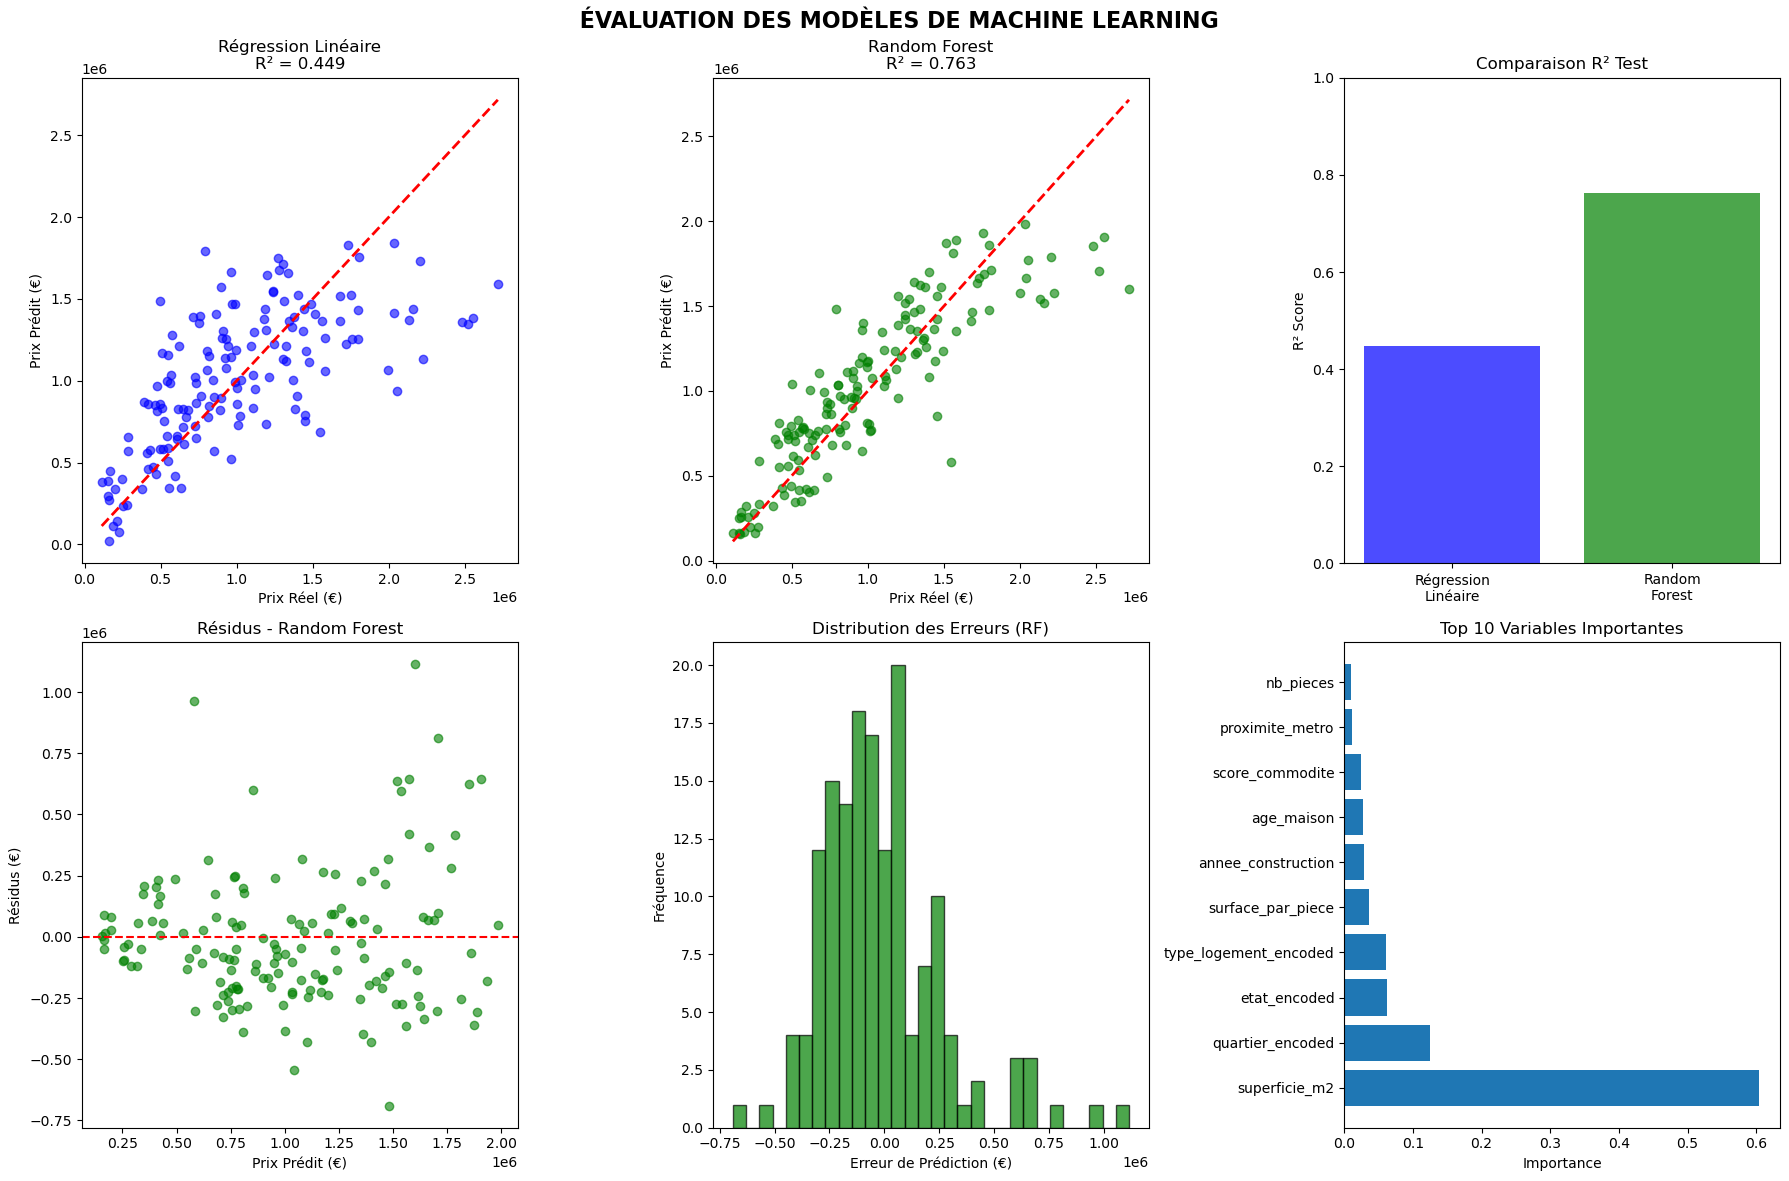


 ANALYSE DES ERREURS (Random Forest) :
   • Erreur moyenne : -14,459€
   • Écart-type erreurs : 274,263€
   • Erreur médiane : 173,126€


In [15]:
# ===============================================================================
# ÉVALUATION AVANCÉE ET VISUALISATIONS
# ===============================================================================

print("\n\nÉVALUATION AVANCÉE DES MODÈLES")
print("-" * 60)

# Comparaison des modèles
comparison_df = pd.DataFrame({
    'Modèle': ['Régression Linéaire', 'Random Forest'],
    'R² Train': [lr_r2_train, rf_r2_train],
    'R² Validation': [lr_r2_val, rf_r2_val],
    'R² Test': [lr_r2_test, rf_r2_test],
    'MAE Test (€)': [lr_mae_test, rf_mae_test],
    'RMSE Test (€)': [lr_rmse_test, rf_rmse_test]
})

print(" COMPARAISON DES MODÈLES :")
print(comparison_df.round(3))

# Visualisations avancées
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(' ÉVALUATION DES MODÈLES DE MACHINE LEARNING', fontsize=16, fontweight='bold')

# 1. Régression Linéaire : Prédictions vs Réalité
axes[0, 0].scatter(y_test, lr_pred_test, alpha=0.6, color='blue')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_title(f'Régression Linéaire\nR² = {lr_r2_test:.3f}')
axes[0, 0].set_xlabel('Prix Réel (€)')
axes[0, 0].set_ylabel('Prix Prédit (€)')

# 2. Random Forest : Prédictions vs Réalité
axes[0, 1].scatter(y_test, rf_pred_test, alpha=0.6, color='green')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_title(f'Random Forest\nR² = {rf_r2_test:.3f}')
axes[0, 1].set_xlabel('Prix Réel (€)')
axes[0, 1].set_ylabel('Prix Prédit (€)')

# 3. Comparaison R² des modèles
models = ['Régression\nLinéaire', 'Random\nForest']
r2_scores = [lr_r2_test, rf_r2_test]
axes[0, 2].bar(models, r2_scores, color=['blue', 'green'], alpha=0.7)
axes[0, 2].set_title('Comparaison R² Test')
axes[0, 2].set_ylabel('R² Score')
axes[0, 2].set_ylim(0, 1)

# 4. Résidus Random Forest
rf_residuals = y_test - rf_pred_test
axes[1, 0].scatter(rf_pred_test, rf_residuals, alpha=0.6, color='green')
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_title('Résidus - Random Forest')
axes[1, 0].set_xlabel('Prix Prédit (€)')
axes[1, 0].set_ylabel('Résidus (€)')

# 5. Distribution des erreurs
axes[1, 1].hist(rf_residuals, bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1, 1].set_title('Distribution des Erreurs (RF)')
axes[1, 1].set_xlabel('Erreur de Prédiction (€)')
axes[1, 1].set_ylabel('Fréquence')

# 6. Importance des variables
top_10_features = feature_importance.head(10)
axes[1, 2].barh(top_10_features['feature'], top_10_features['importance'])
axes[1, 2].set_title('Top 10 Variables Importantes')
axes[1, 2].set_xlabel('Importance')

plt.tight_layout()
plt.show()

# Analyse des erreurs
print(f"\n ANALYSE DES ERREURS (Random Forest) :")
print(f"   • Erreur moyenne : {rf_residuals.mean():,.0f}€")
print(f"   • Écart-type erreurs : {rf_residuals.std():,.0f}€")
print(f"   • Erreur médiane : {np.median(np.abs(rf_residuals)):,.0f}€")

# Maisons les mieux et moins bien prédites
df_test_results = X_test.copy()
df_test_results['prix_reel'] = y_test
df_test_results['prix_predit'] = rf_pred_test
df_test_results['erreur_abs'] = np.abs(y_test - rf_pred_test)


In [18]:
# ===============================================================================
# FONCTION DE PRÉDICTION FINALE 
# ===============================================================================

print("\n\n FONCTION DE PRÉDICTION FINALE")
print("-" * 60)

def predire_prix_maison(superficie, nb_pieces, quartier, type_logement, etat, 
                       annee_construction, balcon, garage, proximite_metro):
    """
    Fonction pour prédire le prix d'une maison avec le modèle Random Forest
    """
    
    # Préparation des features
    age_maison = 2024 - annee_construction
    surface_par_piece = superficie / nb_pieces
    score_commodite = balcon + garage + proximite_metro
    
    # Encodage (en production, sauvegarder les label_encoders)
    quartier_encoded = label_encoders['quartier'].transform([quartier])[0]
    type_encoded = label_encoders['type_logement'].transform([type_logement])[0]
    etat_encoded = label_encoders['etat'].transform([etat])[0]
    
    # Vecteur de features
    features_input = np.array([[
        superficie, nb_pieces, annee_construction, balcon, garage, proximite_metro,
        age_maison, surface_par_piece, score_commodite,
        quartier_encoded, type_encoded, etat_encoded
    ]])
    
    # Prédiction
    prix_predit = rf_model.predict(features_input)[0]
    
    return round(prix_predit, -3)

# Tests de la fonction
print(" TESTS DE LA FONCTION DE PRÉDICTION :")

test_cases = [
    {
        'superficie': 80, 'nb_pieces': 3, 'quartier': 'Centre-ville',
        'type_logement': 'Appartement', 'etat': 'Bon', 'annee_construction': 2015,
        'balcon': 1, 'garage': 0, 'proximite_metro': 1
    },
    {
        'superficie': 150, 'nb_pieces': 5, 'quartier': 'Zone résidentielle',
        'type_logement': 'Maison', 'etat': 'Neuf', 'annee_construction': 2020,
        'balcon': 1, 'garage': 1, 'proximite_metro': 0
    },
    {
        'superficie': 200, 'nb_pieces': 6, 'quartier': 'Banlieue',
        'type_logement': 'Villa', 'etat': 'Bon', 'annee_construction': 2010,
        'balcon': 1, 'garage': 1, 'proximite_metro': 1
    }
]

for i, test in enumerate(test_cases, 1):
    prix = predire_prix_maison(**test)
    print(f"\n Test {i} :")
    print(f"   • {test['superficie']}m², {test['nb_pieces']} pièces, {test['quartier']}")
    print(f"   • {test['type_logement']}, {test['etat']}, {test['annee_construction']}")
    print(f"   • Balcon: {'Oui' if test['balcon'] else 'Non'}, Garage: {'Oui' if test['garage'] else 'Non'}, Métro: {'Oui' if test['proximite_metro'] else 'Non'}")
    print(f"    Prix estimé : {prix:,.0f}€")




 FONCTION DE PRÉDICTION FINALE
------------------------------------------------------------
 TESTS DE LA FONCTION DE PRÉDICTION :

 Test 1 :
   • 80m², 3 pièces, Centre-ville
   • Appartement, Bon, 2015
   • Balcon: Oui, Garage: Non, Métro: Oui
    Prix estimé : 664,000€

 Test 2 :
   • 150m², 5 pièces, Zone résidentielle
   • Maison, Neuf, 2020
   • Balcon: Oui, Garage: Oui, Métro: Non
    Prix estimé : 1,562,000€

 Test 3 :
   • 200m², 6 pièces, Banlieue
   • Villa, Bon, 2010
   • Balcon: Oui, Garage: Oui, Métro: Oui
    Prix estimé : 1,849,000€
